In [15]:
import json
from itertools import product
from pathlib import Path

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from scipy import sparse
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tqdm.auto import tqdm

# 03 — Train models for predicting pIC50 

**Input:** artifacts from `02_fingerprints.ipynb`

**Workflow**

1. **Load** `X`, `y`, metadata, fingerprint config
2. **Scaffold split** → train / val / test indices
3. **Tune** Ridge, Random Forest, and gradient boosting — pick best hyperparameters **per family** using **val RMSE**
4. **Evaluate** each tuned model on val + test; report metrics
5. **Save** to `data/models/` — one artifact per family + metrics CSV

## 1. Load features and labels


In [16]:
DATA_DIR = Path('processed')
MODEL_DIR = Path('models')

X = sparse.load_npz(DATA_DIR / 'X_morgan_r2_b2048.npz')
y = np.load(DATA_DIR / 'y_pIC50.npy')
meta = pd.read_csv(DATA_DIR / 'features_meta.csv')

with open(DATA_DIR / 'fingerprint_config.json') as f:
    fp_config = json.load(f)

assert X.shape[0] == len(meta) == len(y)
print(f'X: {X.shape}  |  y: {y.shape}')
print(f'pIC50 range: {y.min():.2f} - {y.max():.2f}')
fp_config

X: (10834, 2048)  |  y: (10834,)
pIC50 range: 1.60 - 17.30


{'type': 'morgan',
 'radius': 2,
 'n_bits': 2048,
 'use_chirality': True,
 'use_bond_types': True}

## 2. Scaffold split

The point of this section is to determine indices of the molecules that will go to training, validation and test split. Molecules sharing a Murcko scaffold stay in one split. 

A Murcko scaffold is the core ring system of a molecule (rings + linkers), with side chains stripped. Many EGFR inhibitors share the same scaffold with different substituents.

If we split randomly, similar molecules (same scaffold) could end up in both train and test. The model partly “memorizes” scaffolds it saw in training, and test scores look too optimistic.

Scaffold split puts all molecules with the same scaffold in the same split. Test molecules are structurally more novel — a harder, more honest evaluation for drug discovery.


In [17]:
SPLIT_SEED = 42
TRAIN_FRAC = 0.8
VAL_FRAC = 0.1


def murcko_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)


def scaffold_split(smiles_list, train_frac=0.8, val_frac=0.1, seed=0):
    """Assign whole scaffolds to train / val / test."""
    scaffold_to_indices = {}
    for idx, smiles in enumerate(smiles_list):
        scaffold = murcko_scaffold(smiles) or f'__invalid__{idx}'
        scaffold_to_indices.setdefault(scaffold, []).append(idx)

    scaffold_sets = list(scaffold_to_indices.values())
    rng = np.random.default_rng(seed)
    rng.shuffle(scaffold_sets)
    scaffold_sets = sorted(scaffold_sets, key=len, reverse=True)

    n = len(smiles_list)
    train_cutoff = int(n * train_frac)
    val_cutoff = int(n * (train_frac + val_frac))

    train_idx, val_idx, test_idx = [], [], []
    for group in scaffold_sets:
        if len(train_idx) + len(group) <= train_cutoff:
            train_idx.extend(group)
        elif len(train_idx) + len(val_idx) + len(group) <= val_cutoff:
            val_idx.extend(group)
        else:
            test_idx.extend(group)
    return train_idx, val_idx, test_idx


train_idx, val_idx, test_idx = scaffold_split(
    meta['Smiles'].tolist(),
    train_frac=TRAIN_FRAC,
    val_frac=VAL_FRAC,
    seed=SPLIT_SEED,
)

splits = {
    'train': np.array(train_idx, dtype=int),
    'val': np.array(val_idx, dtype=int),
    'test': np.array(test_idx, dtype=int),
}

for name, idx in splits.items():
    print(f'{name:5s}: {len(idx):5,} molecules ({100 * len(idx) / len(meta):.1f}%)')

train: 8,667 molecules (80.0%)
val  : 1,083 molecules (10.0%)
test : 1,084 molecules (10.0%)


## 3. Hyperparameter search (one best model per family)

For each model class we define a **parameter grid**, then:

1. For every combination: **fit on train**, **score RMSE on val**
2. Keep the combination with the **lowest val RMSE**
3. Score that winner on **test** (report only — not used for selection)

Ridge / RF use sparse `X` (float64). Gradient boosting uses LightGBM (sparse) or HistGradientBoosting (dense).


In [18]:
def regression_metrics(y_true, y_pred):
    return {
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'r2': float(r2_score(y_true, y_pred)),
        'pearson': float(np.corrcoef(y_true, y_pred)[0, 1]),
    }


def iter_param_grid(param_grid):
    keys = list(param_grid.keys())
    for values in product(*param_grid.values()):
        yield dict(zip(keys, values))


def tune_on_val(estimator, param_grid, X_train, y_train, X_val, y_val, desc='tuning'):
    """Try every param combo: fit train → score val RMSE; return best."""
    best_val_rmse = float('inf')
    best_model = None
    best_params = None

    param_list = list(iter_param_grid(param_grid))
    for params in tqdm(param_list, desc=desc, unit='config'):
        model = clone(estimator).set_params(**params)
        model.fit(X_train, y_train)
        val_rmse = regression_metrics(y_val, model.predict(X_val))['rmse']
        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_model = model
            best_params = params

    return best_model, best_params


# --- splits ---
X_train = X[splits['train']].astype(np.float64)
X_val = X[splits['val']].astype(np.float64)
X_test = X[splits['test']].astype(np.float64)
y_train = y[splits['train']]
y_val = y[splits['val']]
y_test = y[splits['test']]

# --- model definitions + parameter grids ---
MODEL_SPECS = {
    'ridge': {
        'estimator': Ridge(),
        'param_grid': {
            'alpha': [0.1, 1.0, 10.0, 100.0, 1000.0],
            'solver': ['sparse_cg', 'lsqr'],
        },
        'X_train': X_train,
        'X_val': X_val,
        'X_test': X_test,
    },
    'random_forest': {
        'estimator': RandomForestRegressor(random_state=SPLIT_SEED, n_jobs=-1),
        'param_grid': {
            'n_estimators': [300, 500],
            'max_depth': [None, 20, 40],
            'min_samples_leaf': [1, 5],
            'max_features': ['sqrt', 0.3],
        },
        'X_train': X_train,
        'X_val': X_val,
        'X_test': X_test,
    },
    'lightgbm': {
        'estimator': lgb.LGBMRegressor(random_state=SPLIT_SEED, n_jobs=-1, verbose=-1),
        'param_grid': {
            'learning_rate': [0.05, 0.1],
            'num_leaves': [31, 63],
            'min_child_samples': [20, 50],
            'n_estimators': [400],
        },
        'X_train': X_train,
        'X_val': X_val,
        'X_test': X_test,
    },
}

# --- tune each family ---
best_models = {}
summary_rows = []

for family, spec in MODEL_SPECS.items():
    model, params = tune_on_val(
        spec['estimator'],
        spec['param_grid'],
        spec['X_train'],
        y_train,
        spec['X_val'],
        y_val,
        desc=family,
    )

    val_m = regression_metrics(y_val, model.predict(spec['X_val']))
    test_m = regression_metrics(y_test, model.predict(spec['X_test']))

    best_models[family] = {
        'model': model,
        'best_params': params,
        'metrics': {'val': val_m, 'test': test_m},
    }

    summary_rows.append({
        'model_family': family,
        'best_params': json.dumps(params),
        'val_rmse': val_m['rmse'],
        'val_mae': val_m['mae'],
        'val_r2': val_m['r2'],
        'val_pearson': val_m['pearson'],
        'test_rmse': test_m['rmse'],
        'test_mae': test_m['mae'],
        'test_r2': test_m['r2'],
        'test_pearson': test_m['pearson'],
    })

    print(f'  best val RMSE: {val_m["rmse"]:.4f}  |  test RMSE: {test_m["rmse"]:.4f}')
    print(f'  params: {params}\n')

tuning_results = pd.DataFrame(summary_rows)

ridge: 100%|██████████| 10/10 [00:00<00:00, 18.85config/s]


  best val RMSE: 1.1084  |  test RMSE: 1.0661
  params: {'alpha': 100.0, 'solver': 'lsqr'}



random_forest: 100%|██████████| 24/24 [00:56<00:00,  2.35s/config]


  best val RMSE: 0.9790  |  test RMSE: 0.9386
  params: {'n_estimators': 500, 'max_depth': 40, 'min_samples_leaf': 1, 'max_features': 0.3}



lightgbm: 100%|██████████| 8/8 [00:40<00:00,  5.12s/config]

  best val RMSE: 0.9973  |  test RMSE: 0.9620
  params: {'learning_rate': 0.1, 'num_leaves': 63, 'min_child_samples': 50, 'n_estimators': 400}



## 4. Results — best model per family

One row per model class: hyperparameters chosen on **val**, metrics on **val** and **test**.

**How to read:** lower RMSE / MAE is better; higher R² / Pearson is better. Compare `test_*` columns across families for generalization (test was not used for tuning).

**Plots (test split):** predicted vs measured pIC50 (parity) and residuals vs predicted — visual check of calibration and systematic bias.


In [19]:
display_cols = [
    'model_family', 'val_rmse', 'val_r2', 'val_pearson',
    'test_rmse', 'test_mae', 'test_r2', 'test_pearson', 'best_params',
]
tuning_results[display_cols].sort_values('test_rmse')

,model_family,val_rmse,val_r2,val_pearson,test_rmse,test_mae,test_r2,test_pearson,best_params
1,random_forest,0.979033,0.501637,0.714459,0.938634,0.710458,0.527806,0.740979,"{""n_estimators"": 500, ""max_depth"": 40, ""min_sa..."
2,lightgbm,0.997271,0.482897,0.702502,0.962003,0.722500,0.504001,0.724540,"{""learning_rate"": 0.1, ""num_leaves"": 63, ""min_..."
0,ridge,1.108374,0.361261,0.612985,1.066083,0.835000,0.390871,0.645671,"{""alpha"": 100.0, ""solver"": ""lsqr""}"


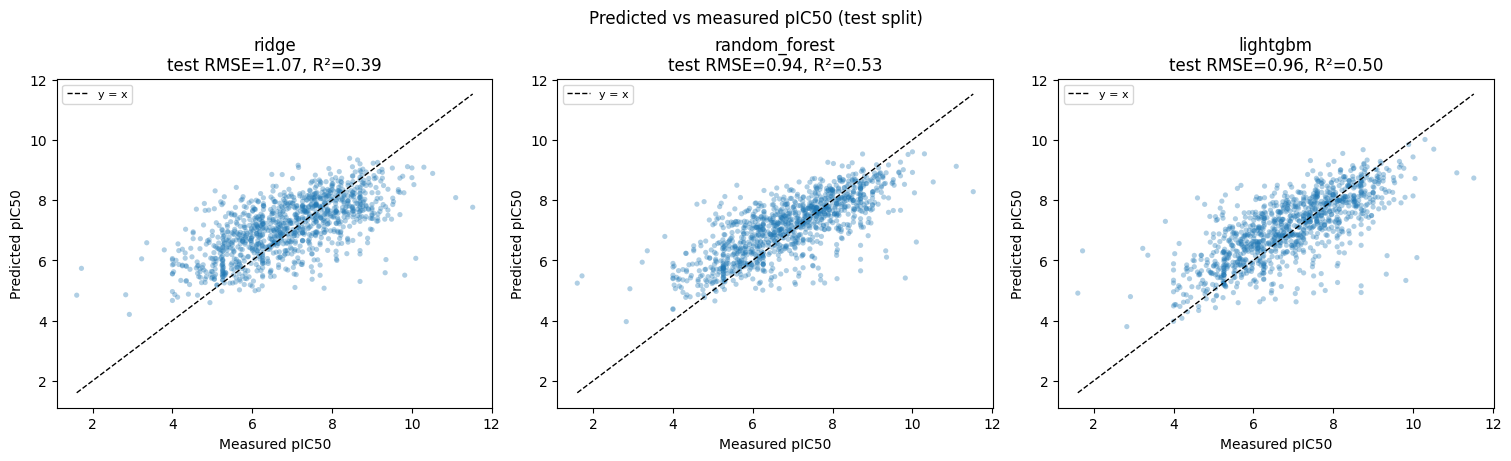

In [20]:
def parity_plot(ax, y_true, y_pred, title):
    ax.scatter(y_true, y_pred, alpha=0.35, s=14, edgecolors='none')
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1, label='y = x')
    ax.set_xlabel('Measured pIC50')
    ax.set_ylabel('Predicted pIC50')
    ax.set_title(title)
    ax.legend(loc='upper left', fontsize=8)


families = list(best_models.keys())
fig, axes = plt.subplots(1, len(families), figsize=(5 * len(families), 4.5), constrained_layout=True)
if len(families) == 1:
    axes = [axes]

for ax, family in zip(axes, families):
    info = best_models[family]
    y_pred = info['model'].predict(MODEL_SPECS[family]['X_test'])
    m = info['metrics']['test']
    parity_plot(
        ax,
        y_test,
        y_pred,
        f'{family}\ntest RMSE={m["rmse"]:.2f}, R²={m["r2"]:.2f}',
    )

fig.suptitle('Predicted vs measured pIC50 (test split)', fontsize=12)
plt.show()

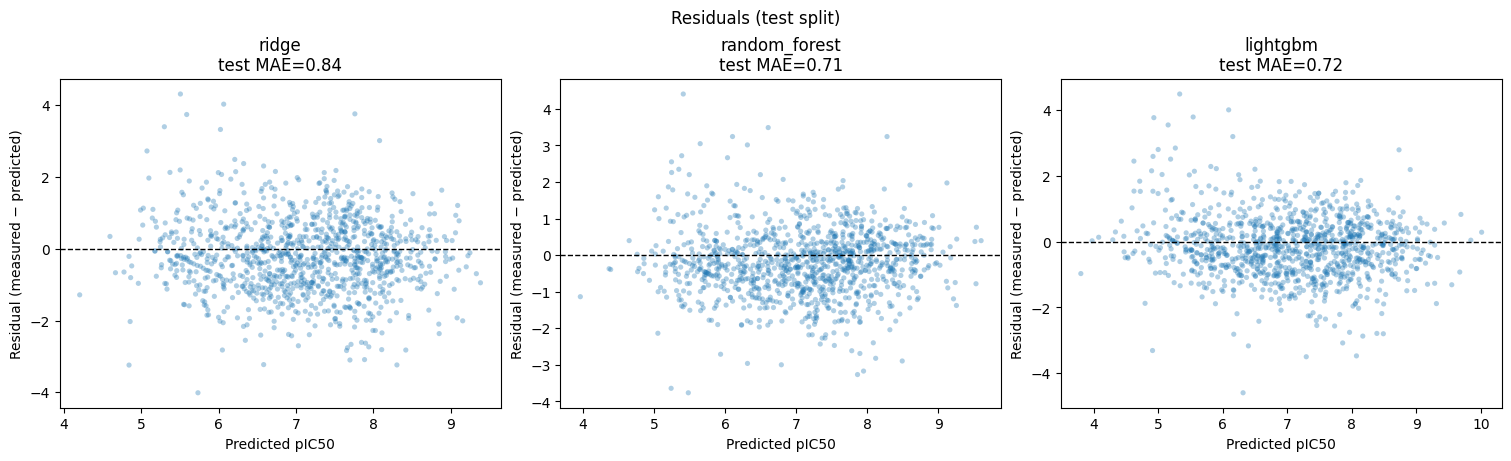

In [ ]:
fig, axes = plt.subplots(1, len(families), figsize=(5 * len(families), 4.5), constrained_layout=True)
if len(families) == 1:
    axes = [axes]

for ax, family in zip(axes, families):
    info = best_models[family]
    y_pred = info['model'].predict(MODEL_SPECS[family]['X_test'])
    residuals = y_test - y_pred
    ax.scatter(y_pred, residuals, alpha=0.35, s=14, edgecolors='none')
    ax.axhline(0, color='k', lw=1, ls='--')
    ax.set_xlabel('Predicted pIC50')
    ax.set_ylabel('Residual (measured -ß predicted)')
    m = info['metrics']['test']
    ax.set_title(f'{family}\ntest MAE={m["mae"]:.2f}')

fig.suptitle('Residuals (test split)', fontsize=12)
plt.show()

## 5. Save models

Writes to `data/models/` (not `processed/` — that folder holds featurized tables and `X`).

One `{family}_best.joblib` per row above: fitted model, `best_params`, `fingerprint_config`, val/test metrics. Summary table → `metrics_all_models.csv`.


In [21]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)

for family, info in best_models.items():
    bundle = {
        'model_family': family,
        'model': info['model'],
        'best_params': info['best_params'],
        'fingerprint_config': fp_config,
        'metrics': info['metrics'],
    }
    joblib.dump(bundle, MODEL_DIR / f'{family}_best.joblib')

tuning_results.to_csv(MODEL_DIR / 'metrics_all_models.csv', index=False)

print(f'Saved models to {MODEL_DIR.resolve()}')

Saved models to /Users/lazarsavic/Desktop/DrugDiscovery/data/models
